In [2]:
# CELDA 1 — Imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

print("Imports OK ✅")

Imports OK ✅


In [3]:
# CELDA 2 — Configuración
# =====================================================================
# MODIFICA AQUÍ: elige el archivo de simulación y la trayectoria
FILE  = "esc_2_4700_064_85_pinn.npy"   # archivo de simulación
TRAJ  = "traj_escenario2_v85.npy"       # trayectoria de referencia
STEP  = 50                               # separación entre índices mostrados
# =====================================================================

sim  = np.load(FILE,  allow_pickle=True).item()
traj = np.load(TRAJ,  allow_pickle=True).item()

N  = len(sim["x"])
dt = float(np.mean(np.diff(sim["time"])))

print(f"Archivo:        {FILE}")
print(f"Pasos totales:  {N}")
print(f"Duración:       {sim['time'][-1] - sim['time'][0]:.1f} s  (dt≈{dt:.3f} s)")
print(f"Velocidad ref:  {traj['V_REF_KMH']} km/h")
print(f"Trayectoria:    {traj['longitud_m']:.0f} m | {traj['n_puntos']} puntos")

Archivo:        esc_2_4700_064_85_pinn.npy
Pasos totales:  3196
Duración:       159.8 s  (dt≈0.050 s)
Velocidad ref:  85.0 km/h
Trayectoria:    3418 m | 170925 puntos


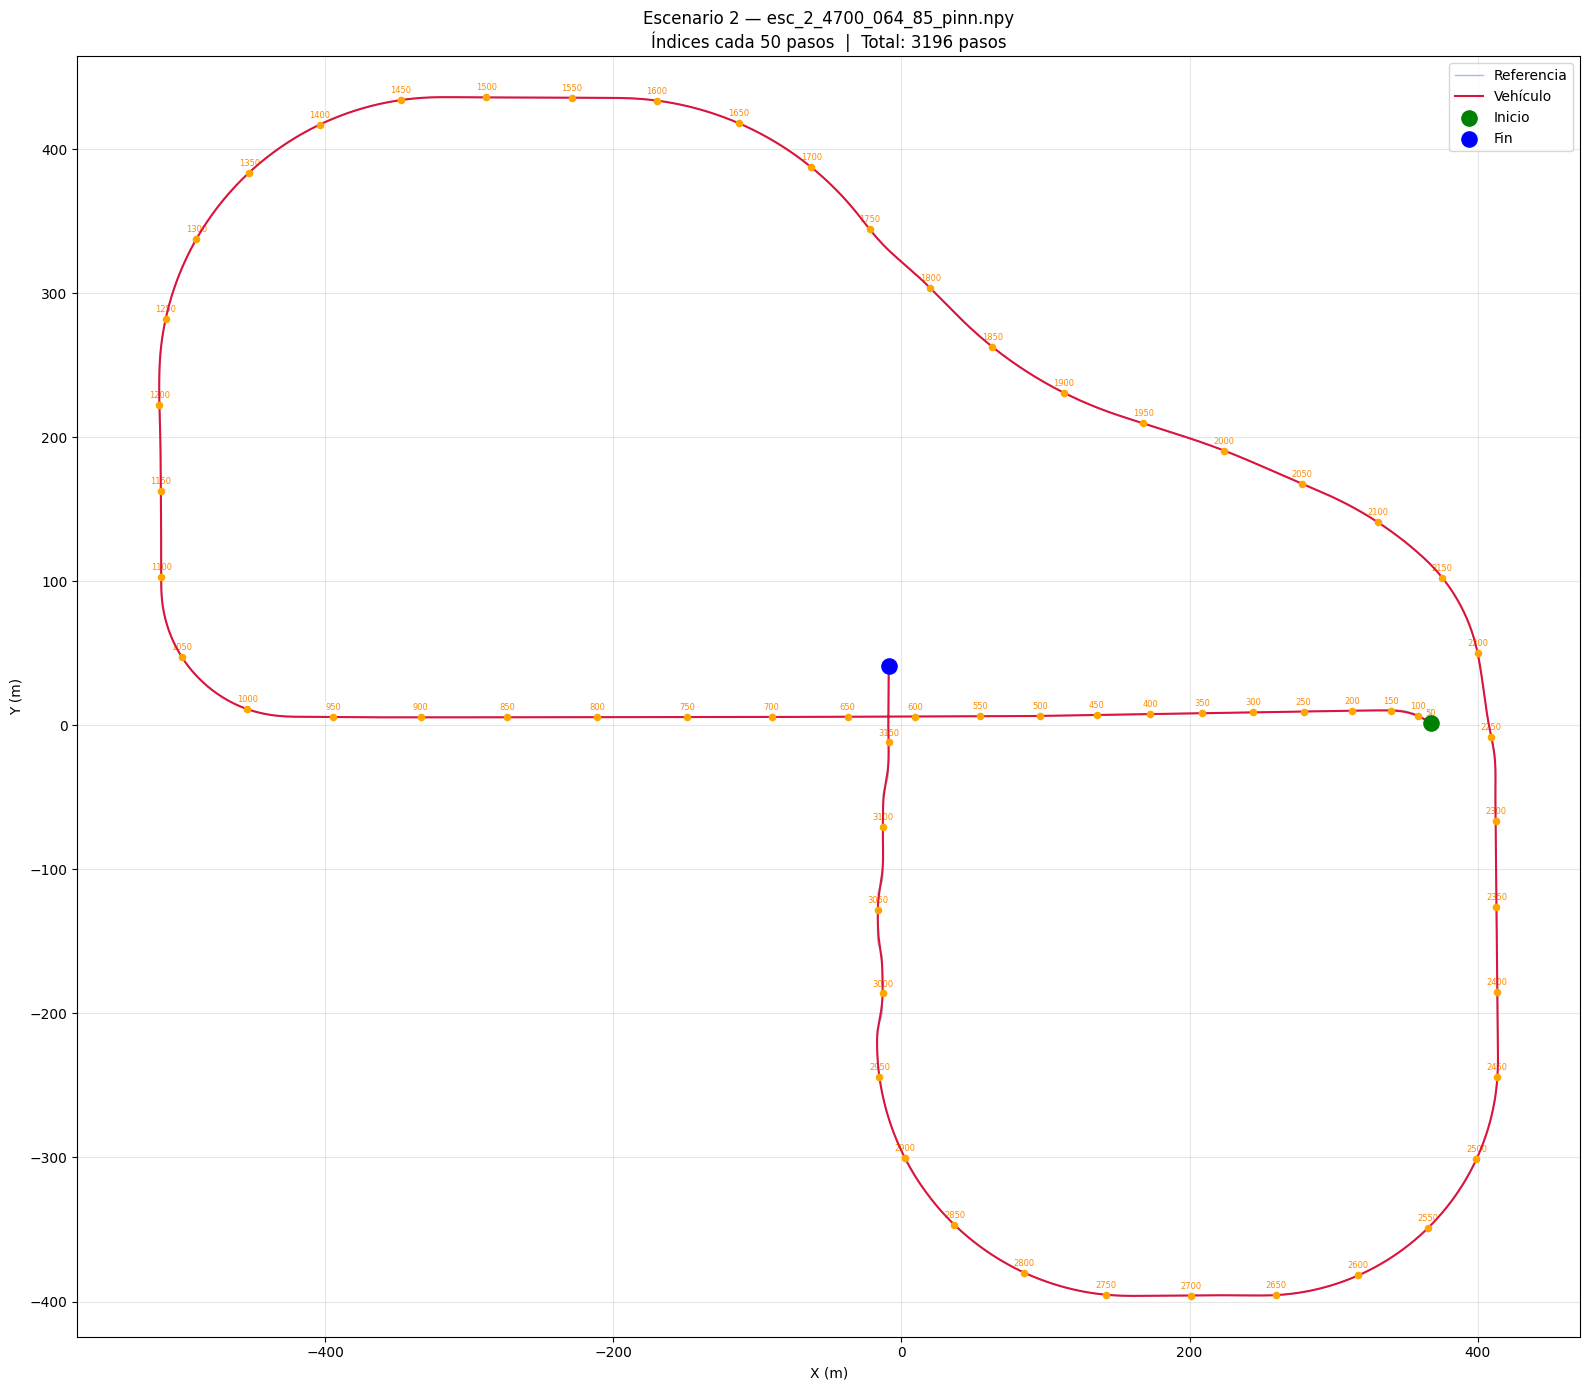

Guardado ✅


In [4]:
# CELDA 3 — Vista general: trayectoria con índices espaciados
# (úsala para identificar el segmento de evaluación)
DECIM = 50

fig, ax = plt.subplots(figsize=(16, 14))

# Referencia
ax.plot(traj["x"][::DECIM], traj["y"][::DECIM],
        color="steelblue", linewidth=1.0, alpha=0.5, label="Referencia")

# Vehículo
ax.plot(sim["x"], sim["y"], color="crimson", linewidth=1.5,
        label="Vehículo", zorder=5)

# Índices espaciados sobre la trayectoria del vehículo
idx_marks = np.arange(0, N, STEP)
ax.scatter(sim["x"][idx_marks], sim["y"][idx_marks],
           s=20, c="orange", zorder=8)
for i in idx_marks:
    ax.annotate(
        str(i),
        xy=(sim["x"][i], sim["y"][i]),
        xytext=(0, 5), textcoords="offset points",
        fontsize=6, ha="center", color="darkorange",
        bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.7)
    )

# Inicio y fin
ax.scatter(sim["x"][0],  sim["y"][0],  s=120, c="green",
           zorder=10, label="Inicio")
ax.scatter(sim["x"][-1], sim["y"][-1], s=120, c="blue",
           zorder=10, label="Fin")

ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)")
ax.set_title(f"Escenario 2 — {FILE}\nÍndices cada {STEP} pasos  |  Total: {N} pasos")
ax.axis("equal"); ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig(FILE.replace(".npy", "_traj.png"), dpi=200, bbox_inches="tight")
plt.show()
print("Guardado ✅")

In [5]:
# CELDA 4 — Selección del segmento de evaluación
# Mira la figura anterior y ajusta estos índices
# =====================================================================
I_EVAL_START = 0    # índice inicial
I_EVAL_END   = N    # índice final (N = hasta el final)
# =====================================================================
ventana = I_EVAL_END - I_EVAL_START
print(f"Segmento de evaluación: [{I_EVAL_START} → {I_EVAL_END}]")
print(f"Pasos en ventana:       {ventana}")
print(f"Duración ventana:       {ventana * dt:.1f} s")

Segmento de evaluación: [0 → 3196]
Pasos en ventana:       3196
Duración ventana:       159.8 s


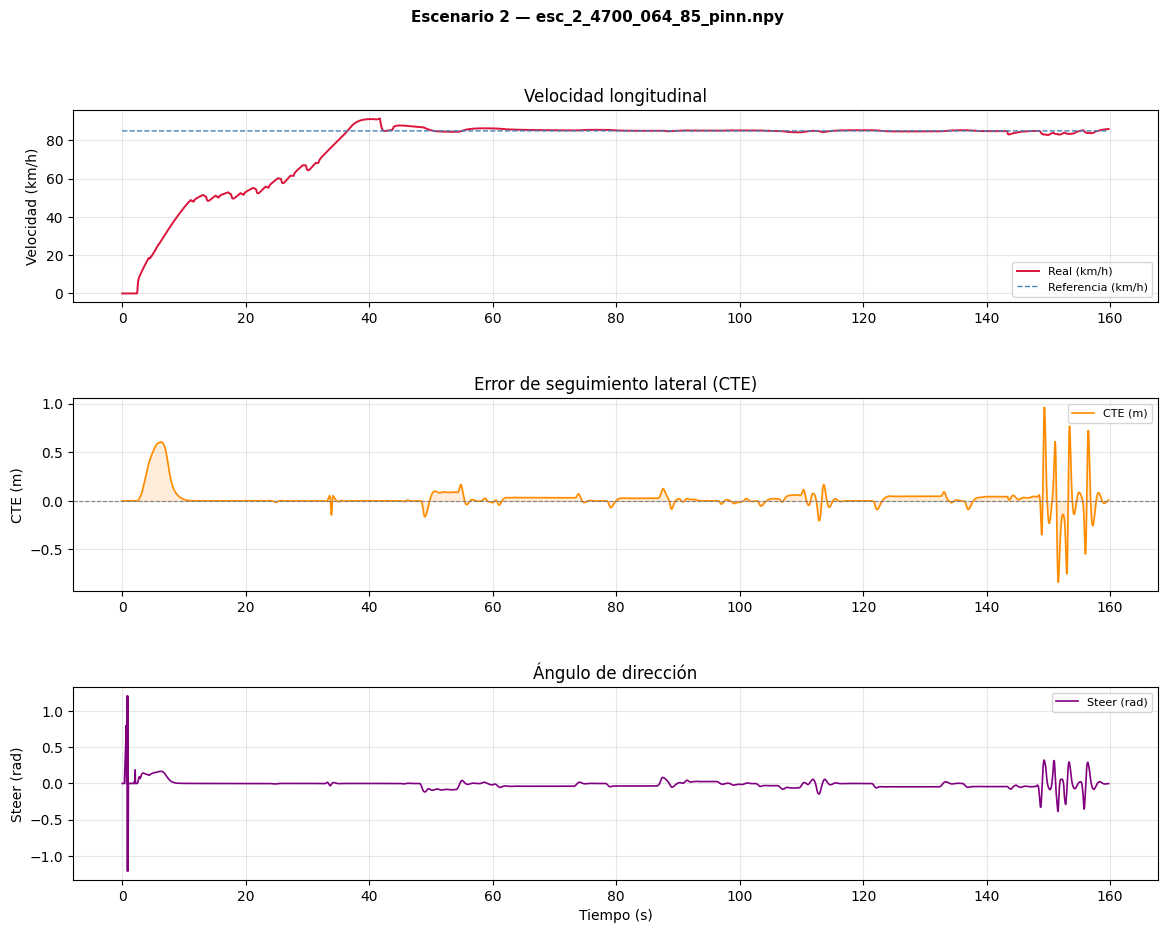

Guardado ✅


In [6]:
# CELDA 5 — Señales: velocidad, CTE y steer en el segmento
sl = slice(I_EVAL_START, I_EVAL_END)
t  = sim["time"][sl] - sim["time"][I_EVAL_START]

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(3, 1, hspace=0.50)

# — Velocidad
ax0 = fig.add_subplot(gs[0])
ax0.plot(t, sim["speed"][sl] * 3.6,
         color="crimson",   linewidth=1.4, label="Real (km/h)")
ax0.plot(t, sim["target_speed"][sl] * 3.6,
         color="steelblue", linewidth=1.0, linestyle="--", label="Referencia (km/h)")
ax0.set_ylabel("Velocidad (km/h)")
ax0.set_title("Velocidad longitudinal")
ax0.legend(fontsize=8); ax0.grid(True, alpha=0.3)

# — CTE
ax1 = fig.add_subplot(gs[1])
cte = sim["crosstrack_error"][sl]
ax1.plot(t, cte, color="darkorange", linewidth=1.2, label="CTE (m)")
ax1.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax1.fill_between(t, cte, 0, alpha=0.15, color="darkorange")
ax1.set_ylabel("CTE (m)")
ax1.set_title("Error de seguimiento lateral (CTE)")
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

# — Steer
ax2 = fig.add_subplot(gs[2])
ax2.plot(t, sim["steer_rad"][sl], color="purple", linewidth=1.2, label="Steer (rad)")
ax2.set_ylabel("Steer (rad)"); ax2.set_xlabel("Tiempo (s)")
ax2.set_title("Ángulo de dirección")
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

fig.suptitle(f"Escenario 2 — {FILE}", fontsize=11, fontweight="bold")
plt.savefig(FILE.replace(".npy", "_signals.png"), dpi=200, bbox_inches="tight")
plt.show()
print("Guardado ✅")

In [7]:
# CELDA 6 — Métricas en el segmento seleccionado
cte_eval   = sim["crosstrack_error"][I_EVAL_START:I_EVAL_END]
steer_eval = sim["steer_rad"][I_EVAL_START:I_EVAL_END]
speed_eval = sim["speed"][I_EVAL_START:I_EVAL_END] * 3.6

rmse_cte = float(np.sqrt(np.mean(cte_eval**2)))
mae_cte  = float(np.mean(np.abs(cte_eval)))
e_max    = float(np.max(np.abs(cte_eval)))
tv_delta = float(np.sum(np.abs(np.diff(steer_eval))))
v_mean   = float(np.mean(speed_eval))
v_min    = float(np.min(speed_eval))

print("═" * 50)
print(f"  Archivo  : {FILE}")
print(f"  Ventana  : [{I_EVAL_START} → {I_EVAL_END}]  ({I_EVAL_END - I_EVAL_START} pasos)")
print("─" * 50)
print(f"  RMSE_cte : {rmse_cte:.4f} m")
print(f"  MAE_cte  : {mae_cte:.4f} m")
print(f"  E_max    : {e_max:.4f} m")
print(f"  TV_δ     : {tv_delta:.4f} rad")
print("─" * 50)
print(f"  V_media  : {v_mean:.1f} km/h")
print(f"  V_min    : {v_min:.1f} km/h")
print("═" * 50)

══════════════════════════════════════════════════
  Archivo  : esc_2_4700_064_85_pinn.npy
  Ventana  : [0 → 3196]  (3196 pasos)
──────────────────────────────────────────────────
  RMSE_cte : 0.1254 m
  MAE_cte  : 0.0522 m
  E_max    : 0.9637 m
  TV_δ     : 20.6880 rad
──────────────────────────────────────────────────
  V_media  : 77.0 km/h
  V_min    : -0.0 km/h
══════════════════════════════════════════════════
